1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Dataset

In [2]:
df = pd.read_csv("../data/telco_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


3. Data Overview

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

4. Churn Distribution

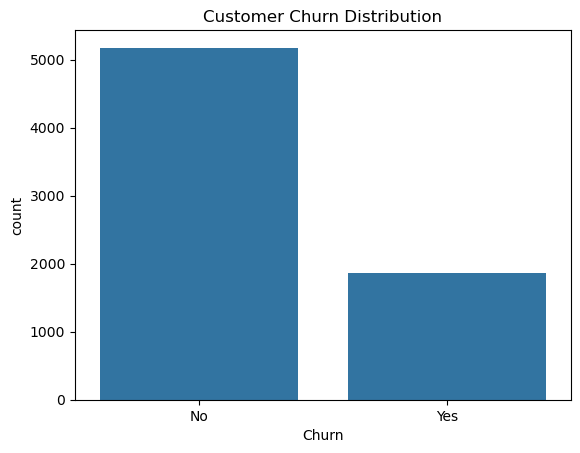

In [13]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.savefig("../images/churn_contract.png")
plt.show()

5. Churn vs Contract

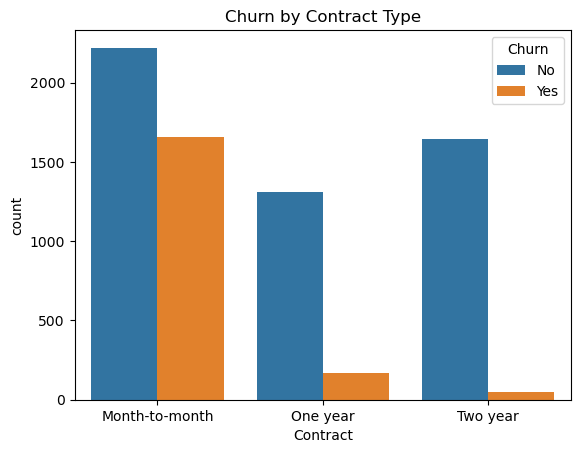

In [14]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")
plt.savefig("../images/churn_internet_service.png")
plt.show()

6. Churn vs Internet Service

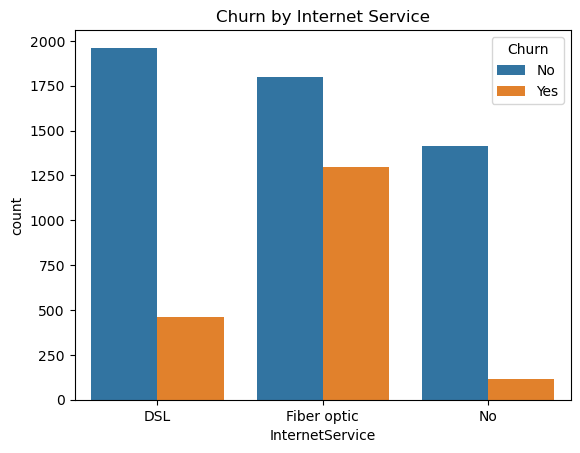

In [15]:
sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Churn by Internet Service")
plt.savefig("../images/monthly_charges_distribution.png")
plt.show()

7. Monthly Charges Analysis

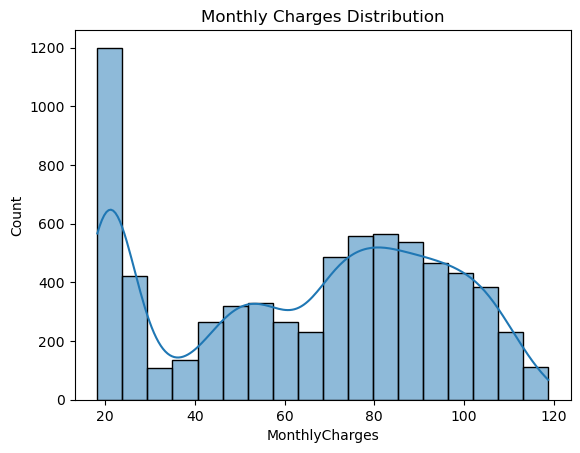

In [16]:
sns.histplot(df["MonthlyCharges"], kde=True)

plt.title("Monthly Charges Distribution")
plt.savefig("../images/monthly_charges_vs_churn.png")
plt.show()

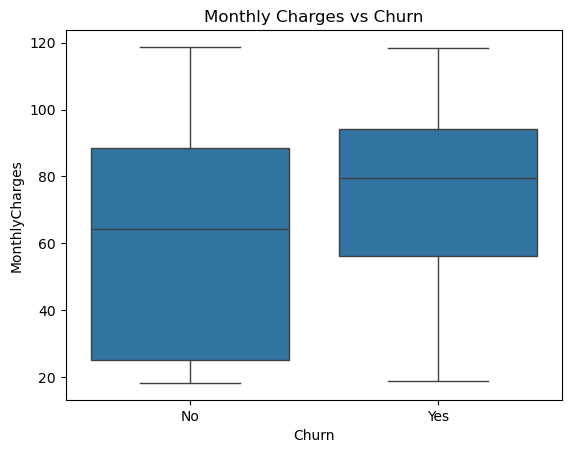

In [17]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.savefig("../images/tenure_distribution.png")
plt.show()

8. Tenure Analysis

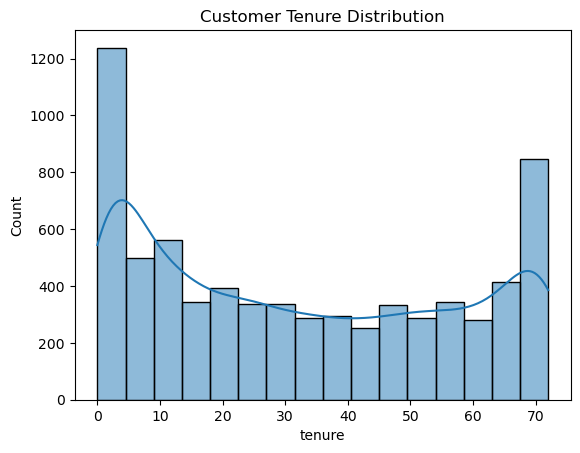

In [18]:
sns.histplot(df["tenure"], kde=True)

plt.title("Customer Tenure Distribution")
plt.savefig("../images/correlation_heatmap.png")
plt.show()

9. Correlation Heatmap

In [11]:
df_encoded = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        df_encoded[col] = le.fit_transform(df_encoded[col])

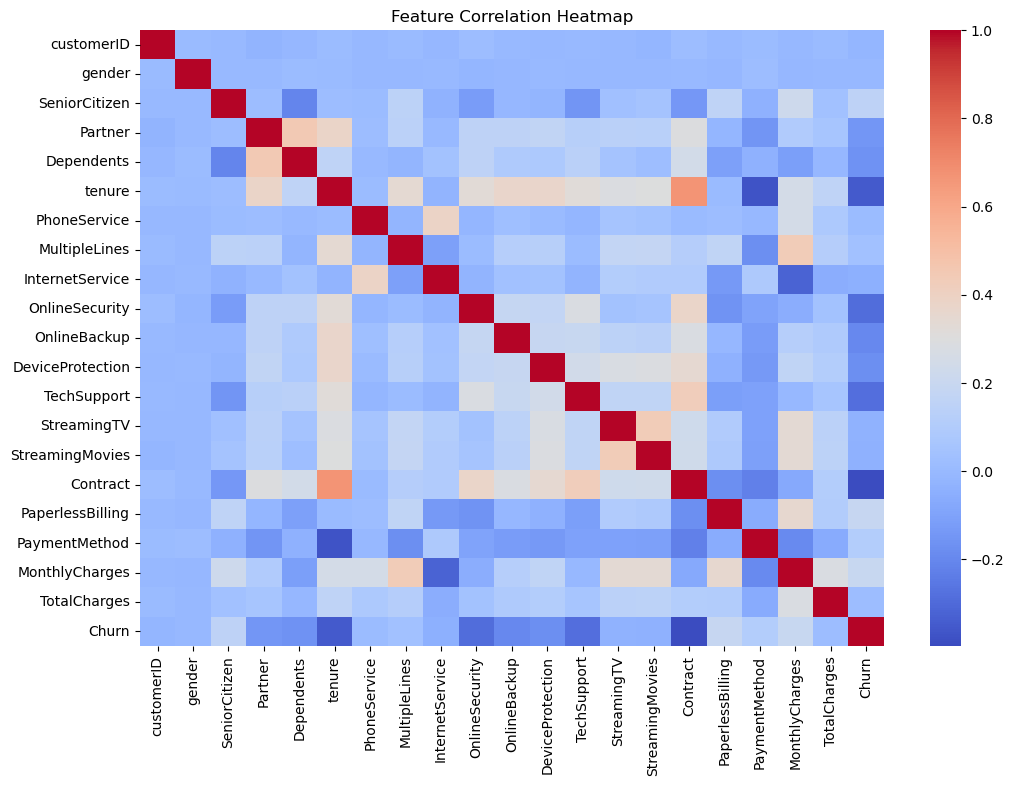

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(df_encoded.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png")
plt.show()

10. Insights

Key Findings:

• Month-to-month contracts have the highest churn
• Customers with high monthly charges churn more
• Customers with low tenure are more likely to leave
• Fiber optic users show higher churn rate